# NESCAC Ice Hockey (M) Principal Component Analysis
## 2022-23 through 2025-26 standings and team stats

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import pandas as pd
import glob


In [3]:
# Find all CSV files in the current folder
csv_files = glob.glob('*.csv')

# Load the first four CSV files
drop_cols = ['Neutral','Neutral Att','Neutral Att Avg','All Att','All Att Avg','All']

df1 = pd.read_csv(csv_files[0]).drop(columns=drop_cols)
df2 = pd.read_csv(csv_files[1]).drop(columns=drop_cols)
df3 = pd.read_csv(csv_files[2]).drop(columns=drop_cols)
df4 = pd.read_csv(csv_files[3]).drop(columns=drop_cols)


## Clean the data, clean clean the data!

In [4]:
# Split combined columns into separate numeric columns
for df in [df1, df2, df3, df4]:
    df[['GF', 'GA']] = df['GF-GA'].str.split(' - ', expand=True).astype(int)
    df.drop(columns=['GF-GA'], inplace=True)

for df in [df1, df2, df3, df4]:
    df[['AVGH', 'AVGV']] = df['AVG Score'].str.split(' - ', expand=True).astype(float)
    df.drop(columns=['AVG Score'], inplace=True)

for df in [df1, df2, df3, df4]:
    df[['Pen Num', 'Pen Min']] = df['Pen'].str.split(' - ', expand=True).astype(str)
    df.drop(columns=['Pen'], inplace=True)

for df in [df1, df2, df3, df4]:
    df['Pen Num'] = df['Pen Num'].str.replace('None', '0').astype(int)
    df['Pen Min'] = df['Pen Min'].str.replace(':00', '').astype(int)


In [5]:
df1["Season"] = "2022–23"
df2["Season"] = "2023–24"
df3["Season"] = "2024–25"
df4["Season"] = "2025–26"
df_all = pd.concat([df1, df2, df3, df4], ignore_index=True)

## Standardize the data before dimension reduction

PCA and t-SNE both depend on distances or variation. Since `Away Att`, `Shots`, `Sav%`, and `Shot%` are on very different scales, we first convert each feature to a z-score.

This means each column is measured in standard deviations from its mean.

In [6]:
df_all["champion"] = (df_all["Standing"] == 1)

features = [
    col for col in df_all.select_dtypes(include="number").columns
    if col not in ["Standing", "champion"]
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_all[features])

## Sample means and variances

These summaries help us notice why scaling matters before PCA.

In [7]:
means = df_all.mean(numeric_only=True)
print('Sample Means:')
print(means)


Sample Means:
Standing           5.50000
GP                25.75000
Margin             0.17450
AST              117.30000
PTS              189.70000
Shots            789.55000
Shot%              0.09225
Saves            698.60000
Sav%               0.91275
PPG               14.37500
SHG                1.40000
Home              12.92500
Home ATT        4157.50000
Home Att Avg     314.02500
Away              12.82500
Away Att        5141.87500
Away Att Avg     391.52500
GF                72.40000
GA                67.10000
AVGH               2.80000
AVGV               2.62000
Pen Num           97.87500
Pen Min          212.17500
champion           0.10000
dtype: float64


In [7]:
variances = df_all.var(numeric_only=True)
print('\nSample Variances:')
print(variances)


Sample Variances:
Standing        8.461538e+00
GP              2.807692e+00
Margin          8.892921e-01
AST             8.127795e+02
PTS             1.931651e+03
Shots           1.328184e+04
Shot%           2.332692e-04
Saves           7.315631e+03
Sav%            2.630641e-04
PPG             2.783013e+01
SHG             1.938462e+00
Home            3.917308e+00
Home ATT        5.868624e+06
Home Att Avg    2.628331e+04
Away            3.071154e+00
Away Att        5.841644e+06
Away Att Avg    2.053933e+04
GF              2.490154e+02
GA              2.061436e+02
AVGH            2.594872e-01
AVGV            3.672821e-01
Pen Num         1.409840e+02
Pen Min         8.852763e+02
champion        9.230769e-02
dtype: float64


## PCA computation

Now we run PCA on the standardized feature matrix.

In [8]:
pca = PCA(n_components=2)
scores = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

array([0.39777568, 0.17681736])

In [9]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=['PC1', 'PC2']
)

loadings

,PC1,PC2
GP,0.269976,0.199956
Margin,0.301304,-0.199315
AST,0.311684,0.103379
PTS,0.316014,0.080339
Shots,0.258198,0.134995
Shot%,0.193330,-0.108410
Saves,-0.040897,0.244119
Sav%,0.183244,-0.235253
PPG,0.274671,0.143849
SHG,-0.024667,-0.096973


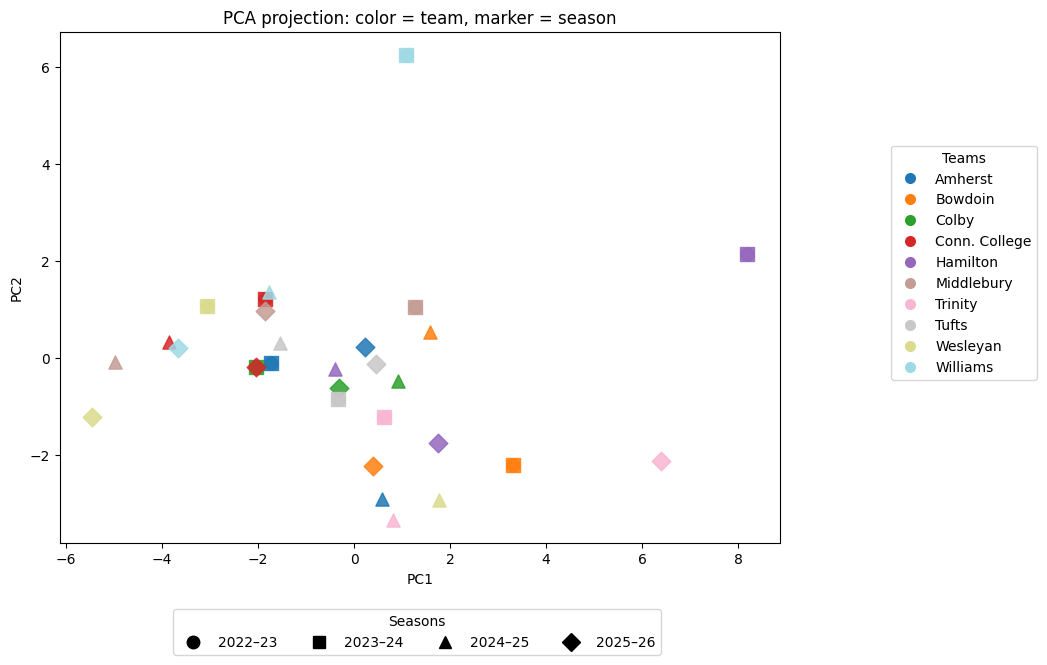

In [9]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

teams = sorted(df_all["Team"].unique())
seasons = sorted(df_all["Season"].unique())

# consistent team colors
import matplotlib as mpl

teams = sorted(df_all["Team"].unique())

cmap = mpl.colormaps["tab20"].resampled(len(teams))
team_color_map = {
    team: cmap(i)
    for i, team in enumerate(teams)
}

markers = {
    "2022–23": "o",
    "2023–24": "s",
    "2024–25": "^",
    "2025–26": "D"
}

fig, ax = plt.subplots(figsize=(11, 7))

for team in teams:
    for season in seasons:
        mask = (df_all["Team"] == team) & (df_all["Season"] == season)

        ax.scatter(
            scores[mask, 0],
            scores[mask, 1],
            color=team_color_map[team],
            marker=markers[season],
            s=90,
            alpha=0.85
        )

ax.set_title("PCA projection: color = team, marker = season")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

team_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=team_color_map[team],
        markersize=9,
        linestyle="",
        label=team
    )
    for team in teams
]

season_handles = [
    Line2D(
        [0], [0],
        marker=markers[season],
        color="black",
        markersize=9,
        linestyle="",
        label=season
    )
    for season in seasons
]

fig.legend(
    handles=team_handles,
    title="Teams",
    loc="center right",
    bbox_to_anchor=(1.02, 0.55)
)

fig.legend(
    handles=season_handles,
    title="Seasons",
    loc="lower center",
    bbox_to_anchor=(0.45, -0.02),
    ncol=4
)

fig.subplots_adjust(right=0.78, bottom=0.15)

plt.show()

# Side Quest: t-SNE Projection

PCA asks:

> Which directions explain the most variation in the data?

t-SNE asks a different question:

> Which teams are near each other, and can we draw a 2D picture that preserves those local neighborhoods?

So PCA is about **variance**. t-SNE is about **neighbors**.

## Distances become neighborhoods

Imagine three teams: A, B, and C.

If B is very close to A in the full statistical data, while C is far away, then t-SNE tries to keep A and B close together in the 2D picture.

But t-SNE does **not** try to preserve every exact distance. It mainly tries to preserve which points are nearby.

## Important warning

In a t-SNE plot:

- nearby points are meaningful,
- clusters can be meaningful,
- the axes do not have natural interpretations,
- large distances between clusters should be interpreted cautiously,
- the shape and size of clusters can be misleading.

This is very different from PCA, where PC1 and PC2 are specific linear combinations of the original variables.

In [11]:
tsne = TSNE(
    n_components=2,
    perplexity=3,
    learning_rate='auto',
    init='pca',
    random_state=42
)

tsne_scores = tsne.fit_transform(X_scaled)

/tmp/ipykernel_5812/599882564.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(teams))


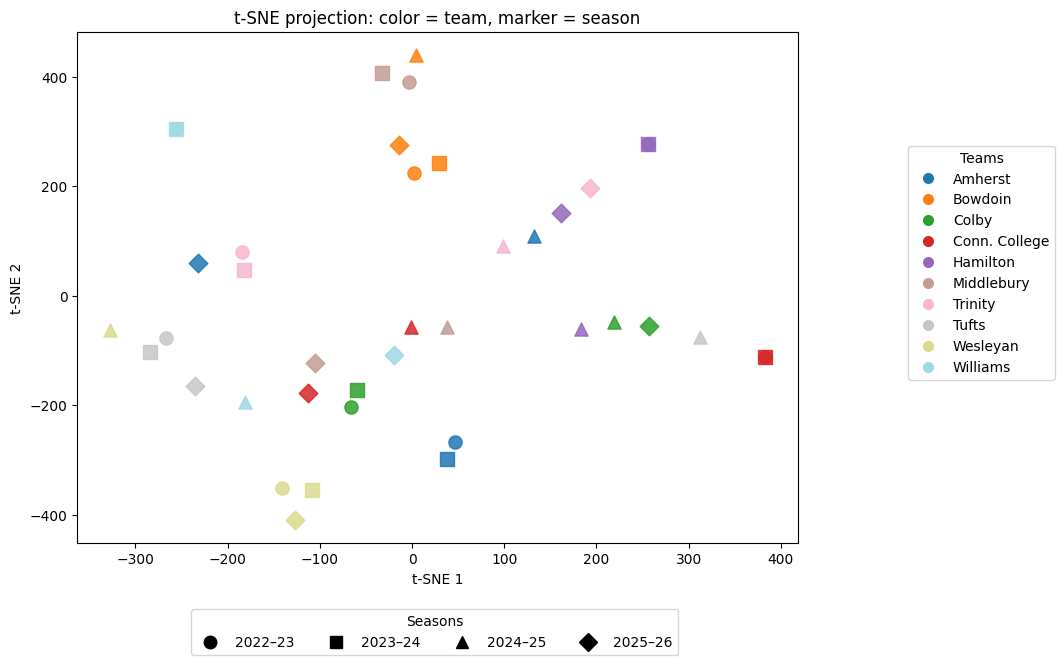

In [24]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np

teams = sorted(df_all["Team"].unique())
seasons = sorted(df_all["Season"].unique())

# Use enough distinct colors for all teams
cmap = plt.cm.get_cmap("tab20", len(teams))
team_color_map = {
    team: cmap(i)
    for i, team in enumerate(teams)
}

markers = {
    "2022–23": "o",
    "2023–24": "s",
    "2024–25": "^",
    "2025–26": "D"
}

fig, ax = plt.subplots(figsize=(11, 7))

for team in teams:
    for season in seasons:
        mask = (df_all["Team"] == team) & (df_all["Season"] == season)

        ax.scatter(
            tsne_scores[mask, 0],
            tsne_scores[mask, 1],
            color=team_color_map[team],
            marker=markers[season],
            s=90,
            alpha=0.85
        )

ax.set_title("t-SNE projection: color = team, marker = season")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

team_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=team_color_map[team],
        markersize=9,
        linestyle="",
        label=team
    )
    for team in teams
]

season_handles = [
    Line2D(
        [0], [0],
        marker=markers[season],
        color="black",
        markersize=9,
        linestyle="",
        label=season
    )
    for season in seasons
]

fig.legend(
    handles=team_handles,
    title="Teams",
    loc="center right",
    bbox_to_anchor=(1.02, 0.55)
)

fig.legend(
    handles=season_handles,
    title="Seasons",
    loc="lower center",
    bbox_to_anchor=(0.45, -0.02),
    ncol=4
)

fig.subplots_adjust(right=0.78, bottom=0.15)

plt.show()

## Reflection questions

A mix of Courtney starting a question and GitHub copilot trying (sometimes successfully) to read her mind.

1. Which teams appear close together in the PCA plot?
2. Which teams appear close together in the t-SNE plot?
3. Are the same teams close together in both plots?
4. Which plot seems better for finding clusters of similar teams?
5. Which plot seems better for explaining which variables matter most?
6. Why should we be careful about interpreting the axes in the t-SNE plot?